# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Proyecto del módulo de fundamentos estadísticos. Se realiza un análisis exploratorio del dataset `diamonds`, incluyendo estadística descriptiva, correlación, prueba de hipótesis y regresión lineal simple.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#from sklearn.linear_model import LinearRegression
from scipy import stats

In [ ]:
df= sns.load_dataset('diamonds')

In [ ]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


# Explotar el dataframe

Veamos cuantos datos y de que tipo tienen cada columna de este dataframe

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


Veamos un resumen estadístico

In [ ]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


Renombrare las columnas para una mejor comprension

In [ ]:
df.rename(columns={
    'carat': 'peso',
    'cut': 'qcorte',
    'color': 'qcolor',
    'clarity': 'pureza',
    'depth': 'prof',
    'table': 'anchurasup',
    'price': 'precio',
    'x': 'largo',
    'y': 'ancho',
    'z': 'altura'
}, inplace=True)

In [ ]:
df.head()

,peso,qcorte,qcolor,pureza,prof,anchurasup,precio,largo,ancho,altura
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Veamos si hay nulos en alguna columna para imputar

In [ ]:
df.isnull().sum(0)

,0
peso,0
qcorte,0
qcolor,0
pureza,0
prof,0
anchurasup,0
precio,0
largo,0
ancho,0
altura,0


Antes de construir modelos predictivos, es importante analizar la relación existente entre las variables numéricas del conjunto de datos. Para ello se utilizará una matriz de correlación, la cual permite identificar qué variables presentan asociaciones lineales más fuertes con el precio del diamante y entre sí.

Este análisis exploratorio permite determinar, de manera preliminar, qué características podrían tener una relación fuerte sobre el precio y cuáles no para futuros modelos de regresión.

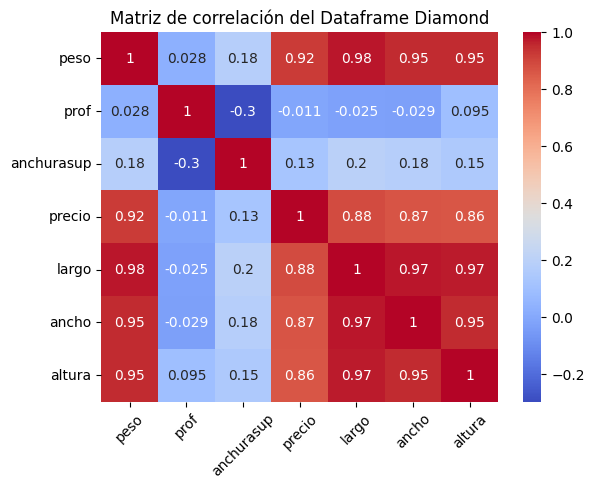

In [ ]:
matriz_corr=df.corr(numeric_only= True)

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación del Dataframe Diamond')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

- `peso` y `precio` presentan una correlación positiva muy alta (`0.92`), indicando que mientras aumenta el peso del diamante, el precio también tiende a aumentar significativamente.

- `largo`, `ancho` y `altura` también muestran correlaciones altas con `precio`, lo que indica que las dimensiones físicas del diamante influyen considerablemente en su valor.

- La correlación entre `peso` y las variables geométricas (`largo`, `ancho`, `altura`) es extremadamente alta (`0.95` a `0.98`), lo que sugiere que estas variables contienen información muy similar relacionada con el tamaño del diamante.

- La variable `prof` presenta correlaciones muy bajas con casi todas las variables, especialmente con `precio`, lo que indica que la profundidad tiene poca relación lineal con el valor del diamante.

- `anchurasup` muestra correlaciones débiles o moderadas con las demás variables, por lo que su influencia sobre el precio parece ser menor en comparación con el peso y las dimensiones físicas.

- La alta correlación entre `peso`, `largo`, `ancho` y `altura` evidencia un caso de multicolinealidad, donde varias variables describen prácticamente la misma característica física del diamante.

# Veamos la validación de la hipótesis

Se realiza una prueba t de Student para comparar el precio promedio entre diamantes con calidad de corte `Ideal` y `Premium`.

H₀: No existe diferencia significativa entre los precios promedio de ambas categorías.

H₁: Existe una diferencia significativa entre los precios promedio de ambas categorías.


In [ ]:
from scipy import stats

ideal = df[df['qcorte'] == 'Ideal']['precio']
premium = df[df['qcorte'] == 'Premium']['precio']

t_stat, p_value = stats.ttest_ind(
    ideal,
    premium,
    equal_var=False
)

print('t-statistic:', t_stat)
print('p-value:', p_value)

t-statistic: -24.917867628750415
p-value: 1.718904661909504e-135


In [ ]:
if p_value < 0.01:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia muy significativa entre los precios promedio de los diamantes Ideal y Premium.")

elif p_value >= 0.01 and p_value < 0.05:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia altamente significativa entre los precios promedio de los diamantes Ideal y Premium.")

elif p_value >= 0.05 and p_value < 0.10:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia moderadamente significativa entre los precios promedio de los diamantes Ideal y Premium.")

else:
    print("\nConclusión: No podemos rechazar la Hipótesis Nula.")
    print("No existe evidencia suficiente para afirmar que los precios promedio de los diamantes Ideal y Premium son diferentes.")


Conclusión: Rechazamos la Hipótesis Nula.
Existe una diferencia muy significativa entre los precios promedio de los diamantes Ideal y Premium.


Dado que el valor-p es muchísimo menor que el nivel de significancia establecido (`α = 0.05`), se rechaza la hipótesis nula.

Esto indica que existe una diferencia estadísticamente significativa entre el precio promedio de los diamantes con calidad de corte `Ideal` y `Premium`.

El estadístico t negativo sugiere que el precio promedio de los diamantes `Ideal` es menor que el de los diamantes `Premium`.

Corroboremos

In [ ]:
print(f'Precio promedio diamantes Ideal: {round(ideal.mean(),3)}\nPrecio promedio diamantes Premium: 'f'{round(premium.mean(),3)}')

Precio promedio diamantes Ideal: 3457.542
Precio promedio diamantes Premium: 4584.258


# Visualizaciones

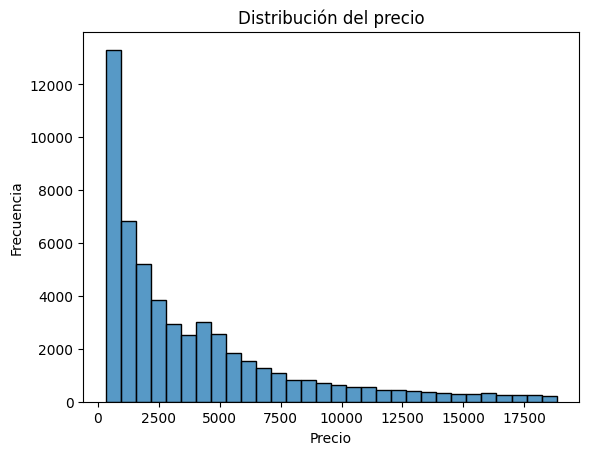

In [ ]:
sns.histplot(
    df['precio'],
    bins=30
)

plt.title('Distribución del precio')
plt.ylabel("Frecuencia")
plt.xlabel("Precio")
plt.show()

La distribución del precio presenta una asimetría positiva (sesgo a la derecha). La mayor parte de los diamantes se concentra en rangos de precios bajos, mientras que los diamantes de precios elevados son menos frecuentes.

Esto indica que el mercado está compuesto principalmente por diamantes de menor valor, existiendo una menor proporción de diamantes excepcionalmente costosos que generan la cola derecha de la distribución. Claro, la demanda tiene que ver. Hay mas gente dispuesta en comprar este tipo de diamantes que los que dispuestos a pagar por los de mayor precio.

Como la distribución no es simétrica:

La media suele ser mayor que la mediana.
Existen valores extremos de precios altos.

Veamos la distribución de color, recordando que:

D → mejor color (más incoloro)

E

F

G

H

I

J → menor calidad de color

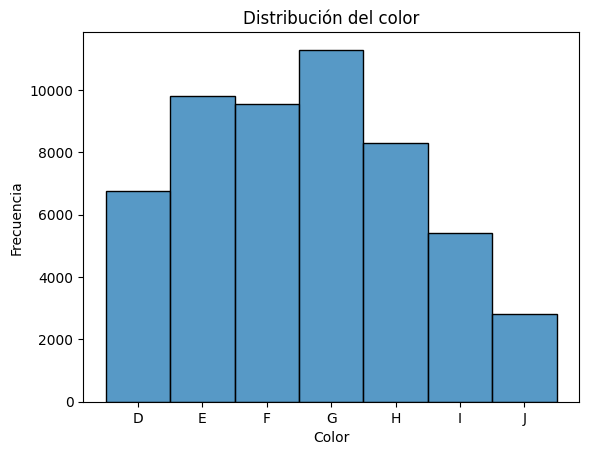

In [ ]:
sns.histplot(
    df['qcolor'],
    bins=100
)

plt.title('Distribución del color')
plt.ylabel("Frecuencia")
plt.xlabel("Color")
plt.show()

La distribución de la variable color muestra que la mayor parte de los diamantes pertenece a las categorías intermedias, siendo G la más frecuente. Las categorías E y F también presentan una alta representación, mientras que los colores I y J son menos comunes.

Esto indica que el conjunto de datos está compuesto principalmente por diamantes de calidad de color media a alta, con una menor proporción de diamantes en las categorías extremas.

Veamos la distribución de la calidad del corte:

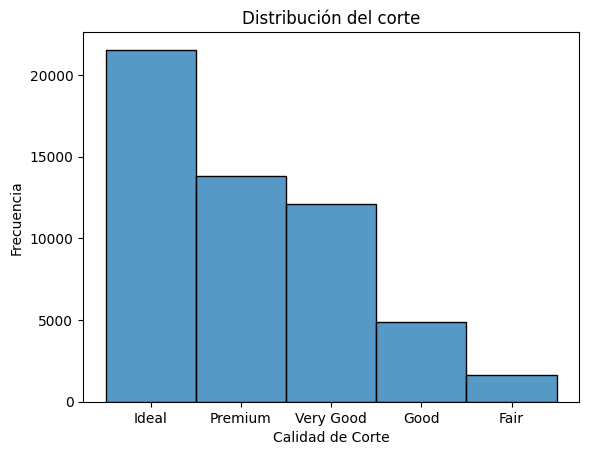

In [ ]:
sns.histplot(
    df['qcorte'],
    bins=100
)

plt.title('Distribución del corte')
plt.ylabel("Frecuencia")
plt.xlabel("Calidad de Corte")
plt.show()

La distribución de la calidad de corte muestra que la categoría más común es "Ideal", mientras que "Fair" presenta la menor cantidad de observaciones.

Esto indica que la mayoría de los diamantes del conjunto de datos poseen una calidad de corte alta, mientras que los diamantes con calidad de corte baja son relativamente escasos. Esto sugiere que el conjunto de datos está compuesto principalmente por diamantes de buena calidad de fabricación, siendo más común encontrar diamantes con cortes optimizados para maximizar el brillo y la apariencia visual que diamantes con cortes deficientes.

Ahora las boxplots:

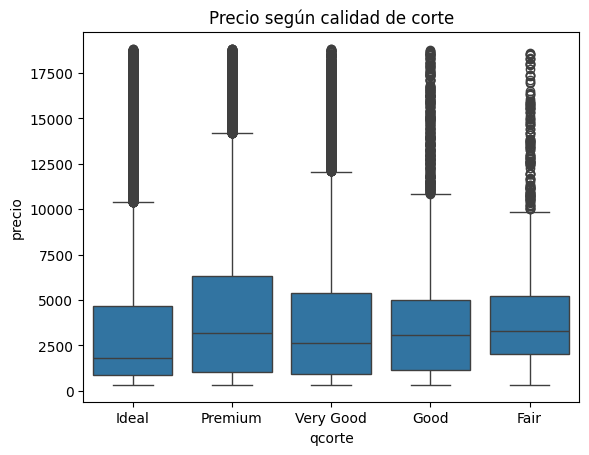

In [ ]:
sns.boxplot(
    data=df,
    x='qcorte',
    y='precio'
)

plt.title('Precio según calidad de corte')
plt.show()

El boxplot muestra una alta dispersión de los precios en todas las categorías de calidad de corte. Se observa una gran cantidad de valores atípicos superiores, lo que indica la existencia de diamantes considerablemente más costosos que el valor típico de cada grupo.

La presencia de numerosos outliers sugiere que el precio no depende únicamente de la calidad del corte, sino también de otras características como el peso, el color y la pureza. Asimismo, las diferencias entre las medianas de las categorías muestran que la calidad de corte influye en el precio, aunque no es el único factor determinante.

De hecho, una observación interesante es que Fair no aparece como la categoría más barata, algo que mucha gente esperaría. Eso sugiere que hay diamantes de corte "regular" pero con mucho peso o alta pureza que elevan bastante su precio.

Hagamos un cambio en los ejes en Y -----------------------------

El boxplot original evidencia una gran cantidad de valores atípicos debido a la fuerte asimetría de la variable precio. Para facilitar la comparación entre categorías hago una versión en escala logarítmica, la cual reduce el efecto visual de los valores extremos sin eliminar observaciones del conjunto de datos.

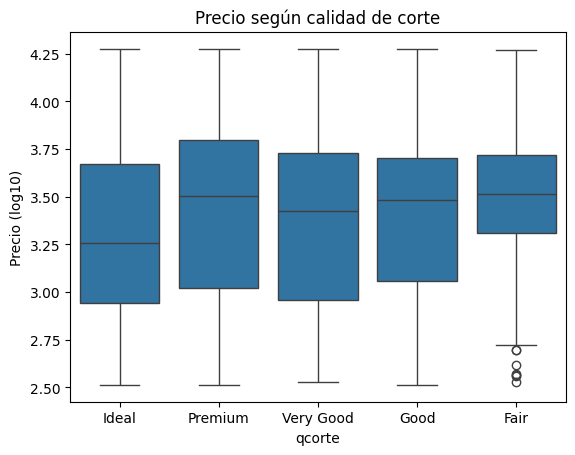

In [ ]:
sns.boxplot(data=df, x='qcorte', y=np.log10(df['precio']))
plt.ylabel("Precio (log10)")
plt.title("Precio según calidad de corte")
plt.show()

Lo mismo para el color

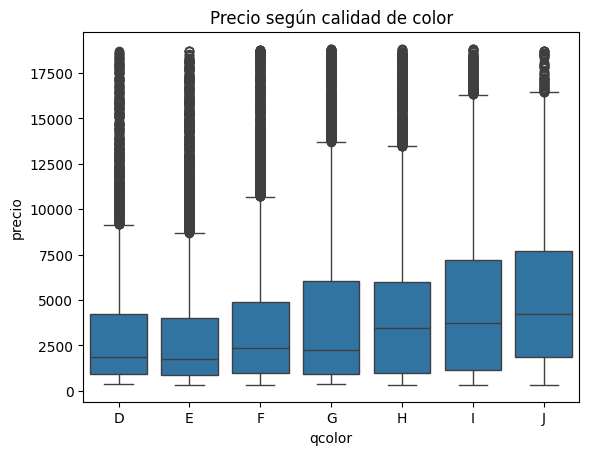

In [ ]:
sns.boxplot(
    data=df,
    x='qcolor',
    y='precio'
)

plt.title('Precio según calidad de color')
plt.show()

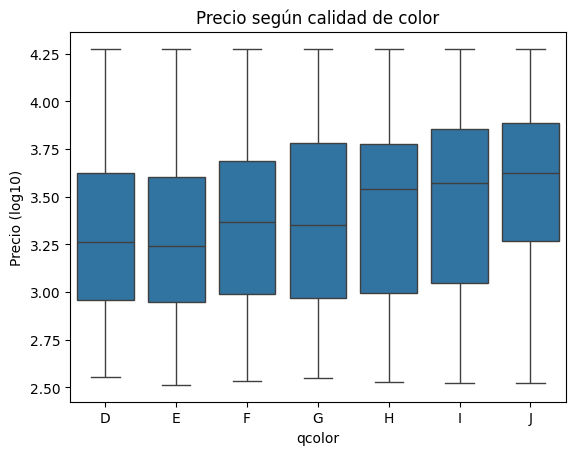

In [ ]:
sns.boxplot(data=df, x='qcolor', y=np.log10(df['precio']))
plt.ylabel("Precio (log10)")
plt.title("Precio según calidad de color")
plt.show()

Veamos finalmente las correlaciones de cada varible númerica

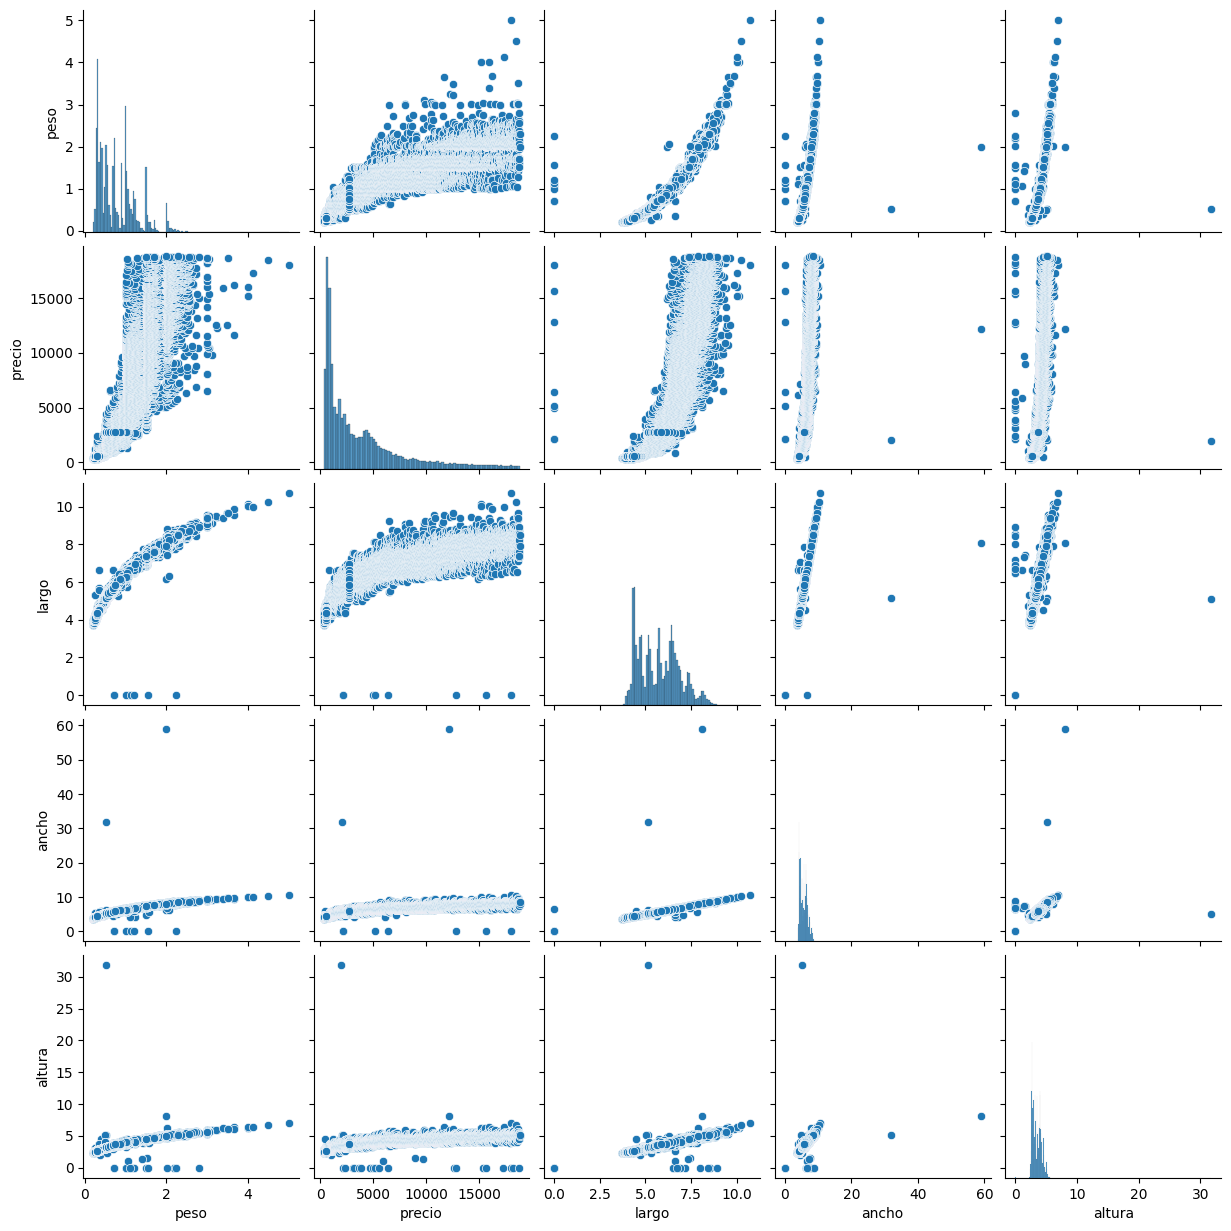

In [ ]:
sns.pairplot(
    df[['peso', 'precio', 'largo', 'ancho', 'altura']]
)

El pairplot confirma las relaciones observadas previamente en la matriz de correlación. El peso presenta una fuerte asociación positiva con el precio, así como con las dimensiones físicas del diamante (largo, ancho y altura). Asimismo, se observa una elevada relación entre las variables geométricas, indicando la presencia de multicolinealidad.

Las distribuciones de peso y precio muestran una asimetría positiva, lo que indica una mayor concentración de diamantes pequeños y de bajo precio, junto con una menor cantidad de observaciones de gran tamaño y alto valor.

También se identifican algunos valores atípicos en las dimensiones físicas, los cuales podrían corresponder a errores de medición o registros anómalos (largo=0, ancho≈60, altura≈30) que no eran tan evidentes en la matriz de correlación. Ademas en todas las relaciones vemos al menos un outlier.

# Regresion lineal y con Descenso de Gradiente

In [ ]:
x = df['peso']
y = df['precio']

In [ ]:
linear_regression = np.polyfit(x, y, 1)
beta, alpha = linear_regression
print(f'y = {beta:.3f} x + {alpha:.3f}')

y = 7756.426 x + -2256.361


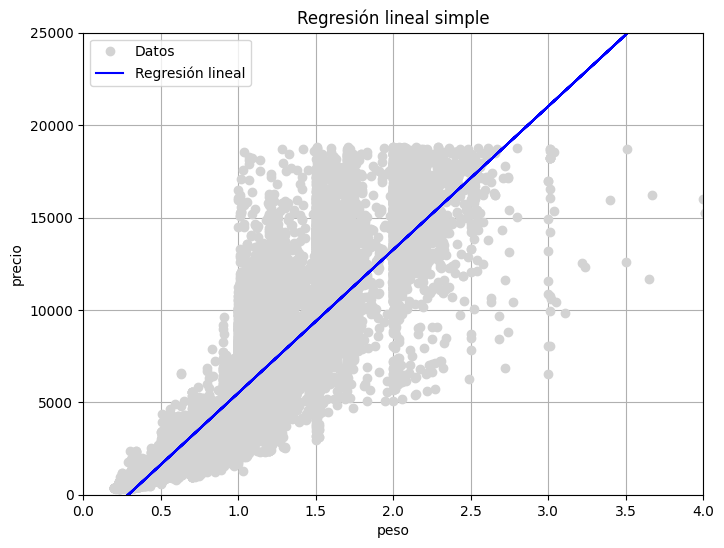

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(x, y, 'o', color = 'lightgray', label = 'Datos')

plt.plot(x, beta*x+alpha, color= 'blue', label = "Regresión lineal")

plt.xlabel("peso")
plt.ylabel("precio")
plt.xlim(0,4)
plt.ylim(0,25000)
plt.grid()
plt.legend()
plt.title("Regresión lineal simple")

plt.show()

Ahora el descenso de gradiente

In [ ]:
tamaño_paso = 0.001
theta_0 = 0
theta_1 = 0

perdida = []

num_iteraciones = 10000

for i in range(num_iteraciones):
    y_pred = theta_1 * x + theta_0
    error = ((y_pred - y) ** 2).mean()
    perdida.append(error)

    d_theta_0 = (2 / len(x)) * np.sum(y_pred - y)
    d_theta_1 = (2 / len(x)) * np.sum((y_pred - y) * x)

    theta_0 = theta_0 - tamaño_paso * d_theta_0
    theta_1 = theta_1 - tamaño_paso * d_theta_1

print(f'y = {theta_1} x + {theta_0}')

y = 7358.130289925945 x + -1891.1595846352566


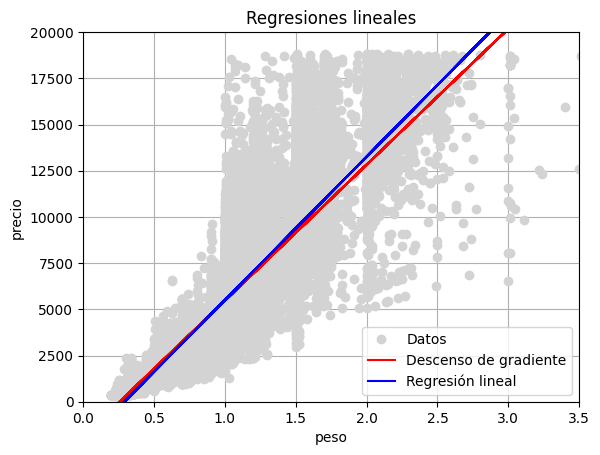

In [ ]:
plt.plot(x, y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, theta_1 * x + theta_0, color = 'red', label = 'Descenso de gradiente')
plt.plot(x, beta*x+alpha, color= 'blue', label = 'Regresión lineal')

plt.xlabel("peso")
plt.ylabel("precio")

plt.title('Regresiones lineales')
plt.xlim(0,3.5)
plt.ylim(0,20000)
plt.legend()
plt.grid()
plt.show()

Honestamente no me gusta mucho la linea, veamos si la de segundo grado hace un mejor trabajo `(\y= x\^2)`

a = 507.913267332659
b = 6677.027341942795
c = -1832.5773716064111


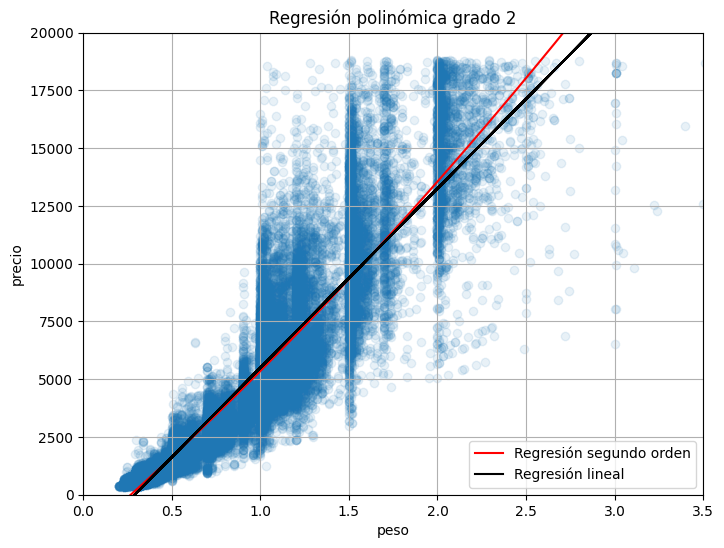

In [ ]:
coef = np.polyfit(x, y, 2)

a, b, c = coef

print("a =", a)
print("b =", b)
print("c =", c)

y_pred = a*x**2 + b*x + c

idx = np.argsort(x)

plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.1)

plt.plot(
    x.iloc[idx],
    y_pred.iloc[idx], color= "red", label= 'Regresión segundo orden')

plt.plot(x, beta*x+alpha, color= 'black', label = 'Regresión lineal')

plt.xlabel("peso")
plt.ylabel("precio")
plt.xlim(0,3.5)
plt.ylim(0,20000)
plt.legend()
plt.grid()
plt.title("Regresión polinómica grado 2")

plt.show()

Aunque el peso presenta una fuerte correlación con el precio, la dispersión observada en los datos indica que existen otros factores relevantes que influyen en el valor del diamante, como la pureza, el color y la calidad del corte. Por ello, una regresión lineal simple captura la tendencia general, pero no explica completamente la variabilidad del precio.

Probablemente con modelos más poderosos o toma de decisiones de árbol, ayuden a mejorar esto. Pero se escapa de los límites de este modulo.

Existe una tendencia creciente que justifica el uso de regresión lineal.

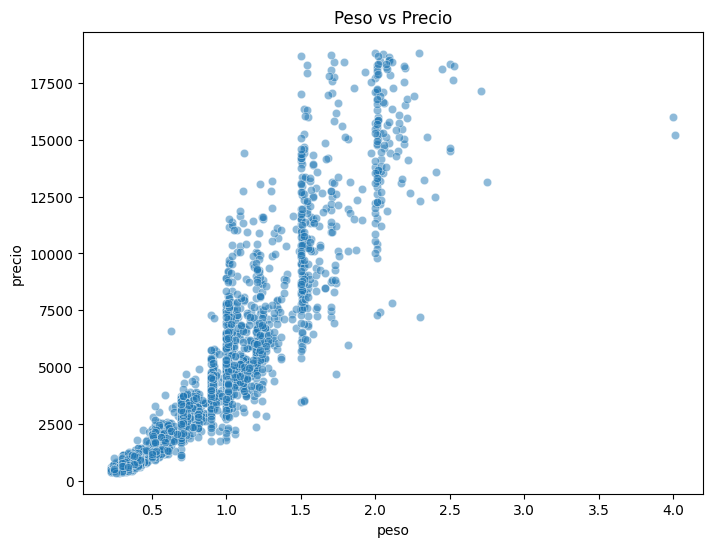

In [ ]:
sample_df = df.sample(3000, random_state=42)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sample_df,
    x='peso',
    y='precio',
    alpha=0.5
)

plt.title('Peso vs Precio')
plt.show()